---
numbering: false
---

# 9.5. Symmetric Matrices and the Spectral Theorem

Symmetric matrices – that is, square matrices where $A = A^T$ – behave **really** nicely through the lens of eigenvectors, and understanding exactly how they work is key to [Chapter 10.1](../10_singular_value_decomposition/01-computing-svd.ipynb), when we generalize beyond square matrices.

While editing these notes, I came across a fitting tweet:

<blockquote class="twitter-tweet"><p lang="en" dir="ltr">Most people with “AI/ML” in their bios don’t even know a real symmetric matrix always has real eigenvalues.</p>&mdash; vixhaℓ (@TheVixhal) <a href="https://twitter.com/TheVixhal/status/2038304484091437080?ref_src=twsrc%5Etfw">March 29, 2026</a></blockquote> <script async src="https://platform.twitter.com/widgets.js" charset="utf-8"></script>

---

## The Spectral Theorem

:::{attention} The Spectral Theorem
If $A$ is an $n \times n$ symmetric matrix with real entries (like all matrices we've studied in this course), then the **spectral theorem** states that:
1. $A$ has exactly $n$ real eigenvalues, counting multiplicities (i.e. none are complex numbers).
1. The eigenvectors for different eigenvalues are orthogonal.
1. For every eigenvalue $\lambda_i$, $\text{GM}(\lambda_i) = \text{AM}(\lambda_i)$.
1. Putting (1), (2), and (3) together, there exists an orthogonal matrix $Q$ and a diagonal matrix $\mathcal{\Lambda}$ such that $$A = Q \mathcal{\Lambda} Q^T$$
    Equivalently, "$A$ can be diagonalized by an orthogonal matrix".
:::

If you search for the spectral theorem online, you'll often just see Statement 4 above; I've broken the theorem into smaller substatements to see how they are chained together.

The proof of Statement 1 is beyond our scope, since it involves fluency with complex numbers. If the term "complex conjugate" means something to you, read the proof [here](https://eecs16b.org/notes/sp24/note14.pdf) – it's relatively short.

The key idea to prove is Statement 2: that for a symmetric matrix, eigenvectors corresponding to different eigenvalues are orthogonal. Suppose $\vec v_i$ is an eigenvector of $A$ with eigenvalue $\lambda_i$ and $\vec v_j$ is an eigenvector of $A$ with eigenvalue $\lambda_j$, where $\lambda_i \neq \lambda_j$. Then

$$A \vec v_i = \lambda_i \vec v_i \qquad \text{and} \qquad A \vec v_j = \lambda_j \vec v_j$$

Consider the dot product $\vec v_i \cdot (A \vec v_j)$. Using the fact that $\vec v_j$ is an eigenvector, we get

$$\vec v_i \cdot (A \vec v_j) = \vec v_i \cdot (\lambda_j \vec v_j) = \lambda_j (\vec v_i \cdot \vec v_j)$$

But we can also rewrite the same quantity using the fact that $A$ is symmetric:

$$\vec v_i \cdot (A \vec v_j) = \vec v_i^T A \vec v_j = \vec v_i^T A^T \vec v_j = (A \vec v_i)^T \vec v_j = \lambda_i \vec v_i^T \vec v_j = \lambda_i (\vec v_i \cdot \vec v_j)$$

So,

$$\lambda_j (\vec v_i \cdot \vec v_j) = \lambda_i (\vec v_i \cdot \vec v_j)$$

which means

$$(\lambda_j - \lambda_i)(\vec v_i \cdot \vec v_j) = 0$$

Since $\lambda_i \neq \lambda_j$, the first factor is non-zero, so we must have $\vec v_i \cdot \vec v_j = 0$. Therefore, eigenvectors corresponding to different eigenvalues are orthogonal.

For a given eigenvector direction, we can pick any vector in that direction to be the eigenvector we store in the $V$ that we use to diagonalize $A$ – if $\vec v$ is an eigenvector, so is $2 \vec v$, $-3 \vec v$, $\frac{\vec v}{\lVert \vec v \rVert}$, and so on. The convenient choice is to pick unit vectors in each direction. If we take these $n$ unit eigenvectors and place them in the columns of a matrix, that matrix is an orthogonal matrix! Orthogonal matrices $Q$ satisfy $Q^TQ = QQ^T = I$, meaning their columns (and rows) are ortho**normal**, not just orthogonal to one another. The fact that $Q^TQ = QQ^T = I$ means that $Q^T = Q^{-1}$, so taking the transpose of a matrix is the same as taking its inverse.

$$A = V \Lambda V^{-1}$$

we've "upgraded" to

$$A = Q \Lambda Q^T$$

**This is the main takeaway of the spectral theorem: that symmetric matrices can be diagonalized by an orthogonal matrix.** Sometimes, $A = Q \Lambda Q^T$ is called the **spectral decomposition** of $A$, but all it is is a special case of the eigenvalue decomposition for symmetric matrices.

### Visualizing the Spectral Theorem

Why do we prefer $Q \Lambda Q^T$ over $V \Lambda V^{-1}$? Taking the transpose of a matrix is much easier than inverting it, so actually working with $Q \Lambda Q^T$ is easier. 

$$\underbrace{A = Q \Lambda Q^T \implies A^k = Q \Lambda^k Q^T}_{\text{no inversion needed!}}$$

But it's also an improvement in terms of **interpretation**: remember that orthogonal matrices are matrices that represent rotations. So, if $A$ is symmetric, then the linear transformation $f(\vec x) = A \vec x$ is a sequence of rotations and stretches.

$$f(\vec x) = A \vec x = Q \Lambda Q^T \vec x$$

Let's make sense of this visually. Consider the symmetric matrix $A = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix}$.

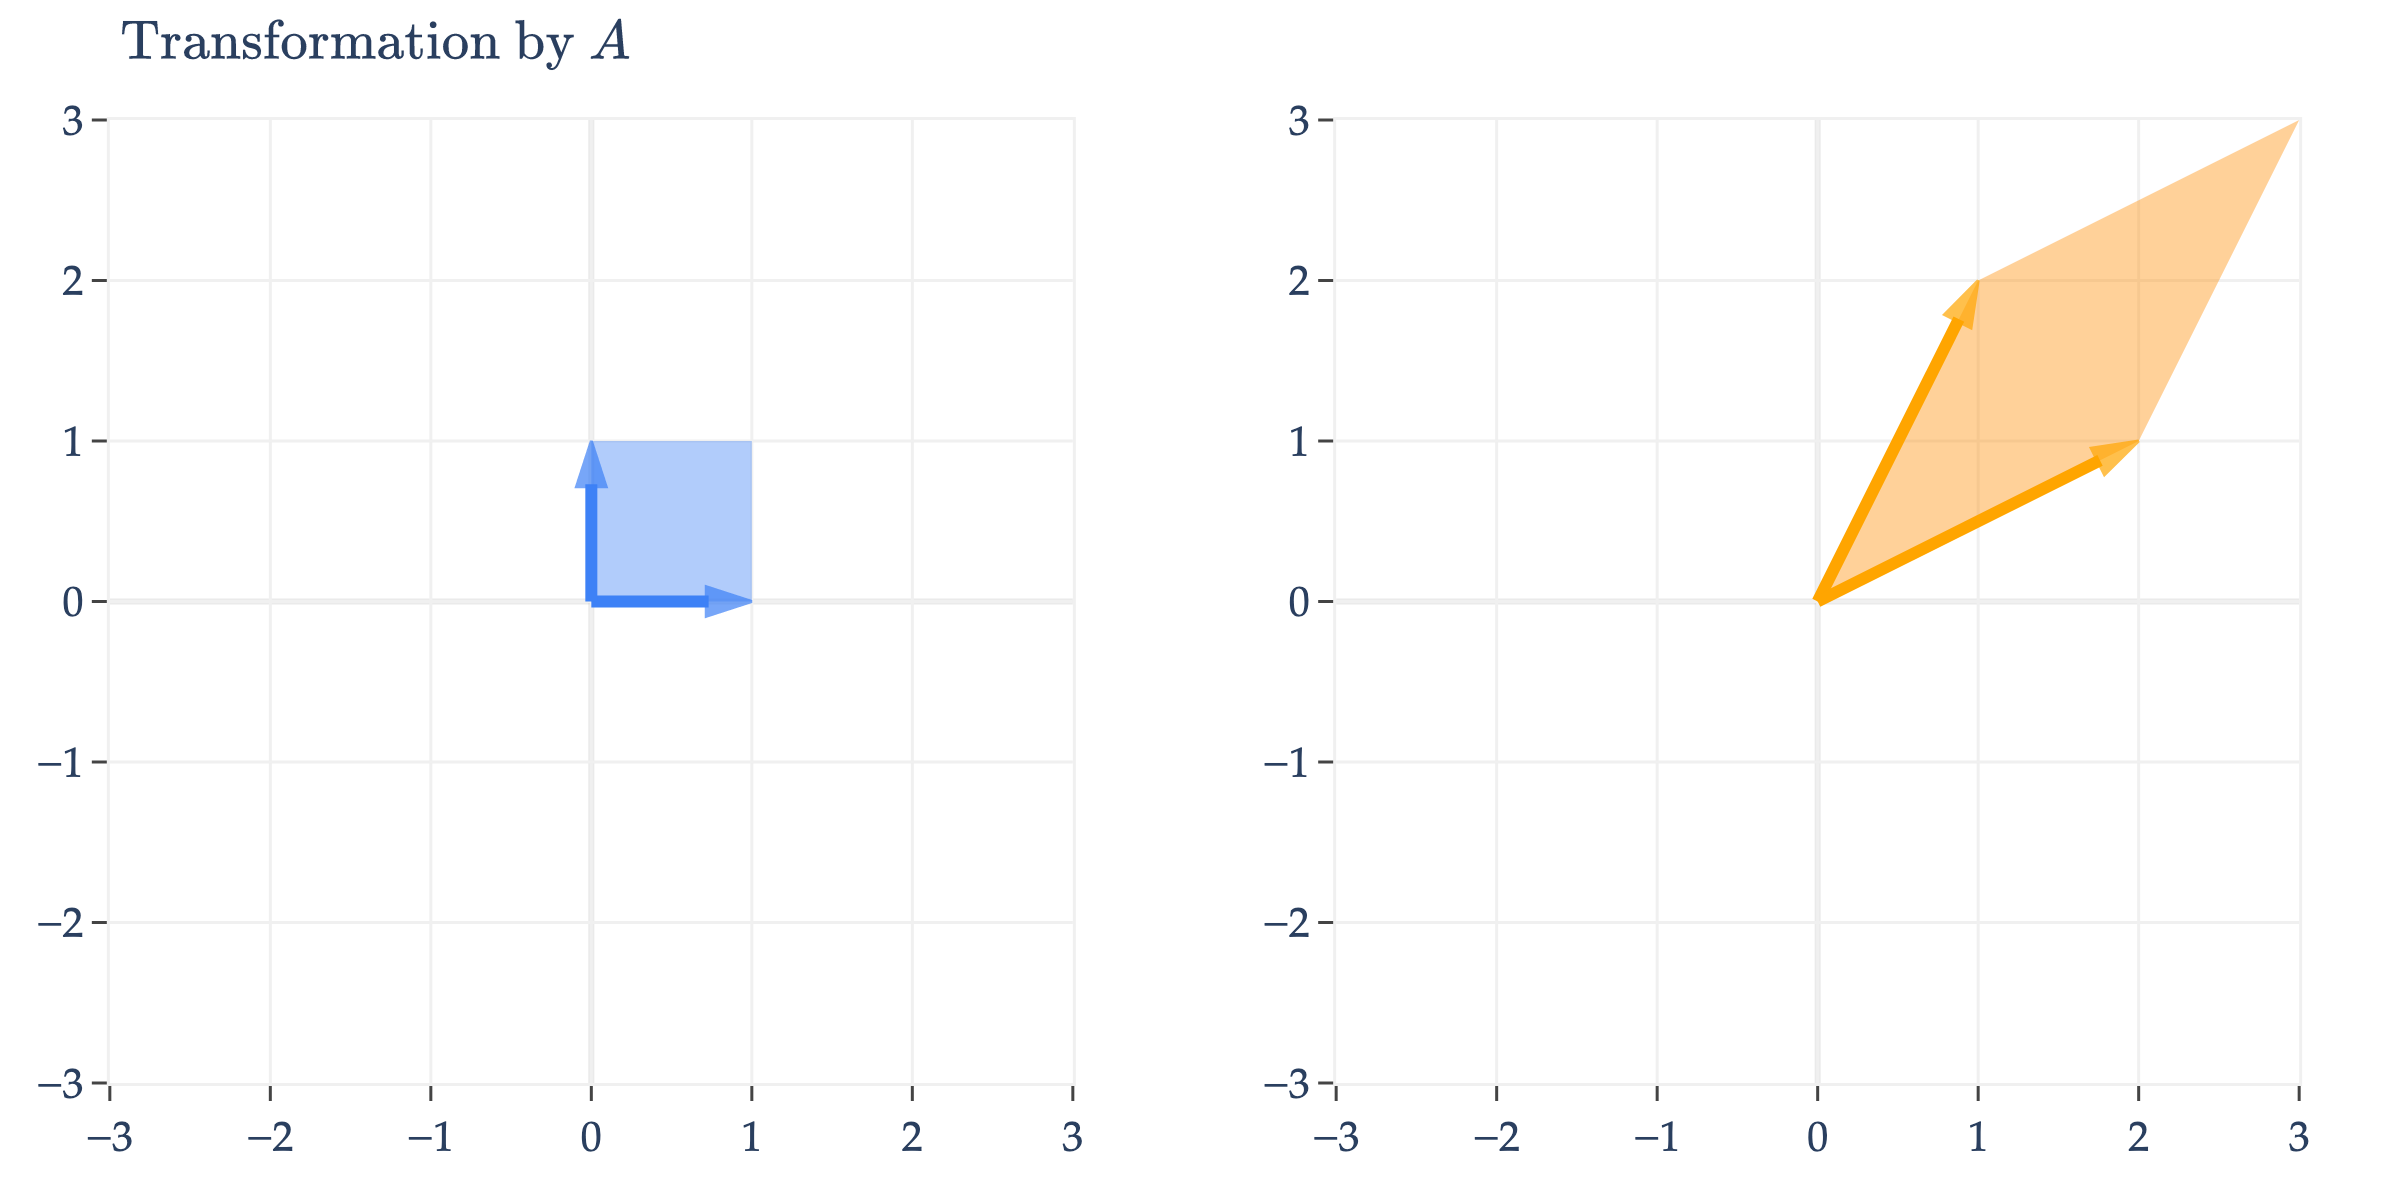

In [35]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from utils import plot_vectors

def plot_unit_square_and_transform(
    A=None, 
    B=None, 
    name_A="A", 
    name_B="B", 
    vdeltax_A=-0.3, 
    vdeltay_A=0.2, 
    vdeltax_B=0.5, 
    vdeltay_B=0, 
    return_fig=False, 
    show_labels=True,
    axis_range=[-3.5, 3.5],
    title=''
):
    """
    Visualize transformation of the unit square and basis vectors under two matrices.
    Left: vectors A u_x and A u_y and parallelogram from A (default is identity -- the unit square and basis)
    Right: vectors B u_x and B u_y and parallelogram from B (default is the input B)
    """
    # Default: left is unit, right is input (legacy)
    if A is None:
        A = np.eye(2)
    if B is None:
        B = np.eye(2)
        
    # Vertices of the unit square
    square = np.array([
        [0, 0],  # A
        [1, 0],  # B
        [1, 1],  # C
        [0, 1],  # D
        [0, 0]   # A (to close the square)
    ])
    square_A = (A @ square.T).T
    square_B = (B @ square.T).T

    # Create subplot figure
    left_title = r"$$" + name_A + r"\vec u_x \text{  and } " + name_A + r"\vec u_y$$" if (name_A and show_labels) else ""
    right_title = r"$$" + name_B + r"\vec u_x \text{  and } " + name_B + r"\vec u_y$$" if (name_B and show_labels) else ""
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(left_title, right_title),
        horizontal_spacing=0.08,
    )

    # Common axis settings
    axis_style = dict(
        showgrid=True,
        gridcolor="#f0f0f0",
        zeroline=False,  # We'll add our own zero lines
        showline=True,
        linecolor="#f0f0f0",
        mirror=True,
        ticks="outside",
        showticklabels=True,
        tickfont=dict(family="Palatino, serif", size=14),
    )
    # Set axis ranges to [-4, 4] for both subplots
    for i in [1, 2]:
        fig.update_xaxes(
            range=axis_range,
            constrain="domain",
            dtick=1,
            **axis_style,
            row=1, col=i
        )
        fig.update_yaxes(
            range=axis_range,
            scaleanchor=f"x{i}",
            dtick=1,
            **axis_style,
            row=1, col=i
        )
    # --- Draw faint 0 grid lines underneath everything else ---
    for i in [1, 2]:
        # Horizontal y=0
        fig.add_shape(
            type="line",
            x0=-4, x1=4, y0=0, y1=0,
            line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
            row=1, col=i,
            layer="below"
        )
        # Vertical x=0
        fig.add_shape(
            type="line",
            x0=0, x1=0, y0=-4, y1=4,
            line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
            row=1, col=i,
            layer="below"
        )

    # -- Plot left parallelogram (A unit square) in blue
    fig.add_trace(
        go.Scatter(
            x=square_A[:,0], y=square_A[:,1],
            fill="toself",
            fillcolor="rgba(61,129,246,0.4)",
            line=dict(color="rgba(0,0,0,0)", width=0),  # No perimeter
            name=f"{name_A} square",
            showlegend=False
        ),
        row=1, col=1
    )
    # -- Plot right parallelogram (B unit square) in orange
    fig.add_trace(
        go.Scatter(
            x=square_B[:,0], y=square_B[:,1],
            fill="toself",
            fillcolor="rgba(255,140,0,0.4)",
            line=dict(color="rgba(0,0,0,0)", width=0),
            name=f"{name_B} square",
            showlegend=False
        ),
        row=1, col=2
    )

    # --- Draw vectors using plot_vectors ---
    # Standard basis vectors
    u_x = np.array([1, 0])
    u_y = np.array([0, 1])

    # Left: A u_x, A u_y in #3d81f6
    Au_x = A @ u_x
    Au_y = A @ u_y
    if show_labels:
        left_vecs = [
            (tuple(Au_x), '#3d81f6', rf'${name_A}\vec u_x$'),
            (tuple(Au_y), '#3d81f6', rf'${name_A}\vec u_y$'),
        ]
    else:
        left_vecs = [
            (tuple(Au_x), '#3d81f6', None),
            (tuple(Au_y), '#3d81f6', None),
        ]
    left_fig = plot_vectors(left_vecs, vdeltax=vdeltax_A, vdeltay=vdeltay_A)
    left_fig.update_layout(
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        margin=dict(l=0, r=0, t=0, b=0)
    )
    # Add the vector traces to the left subplot
    for trace in left_fig.data:
        fig.add_trace(trace, row=1, col=1)
    # Add the vector annotations to the left subplot, if enabled
    if show_labels:
        for ann in left_fig.layout.annotations:
            if hasattr(ann, "to_plotly_json"):
                ann_dict = ann.to_plotly_json()
            else:
                ann_dict = dict(ann)
            ann_dict = {k: v for k, v in ann_dict.items() if k not in {"xref", "yref", "axref", "ayref"}}
            fig.add_annotation(**ann_dict, row=1, col=1)

    # Right: B u_x, B u_y in orange
    Bu_x = B @ u_x
    Bu_y = B @ u_y
    if show_labels:
        right_vecs = [
            (tuple(Bu_x), 'orange', rf'${name_B}\vec u_x$'),
            (tuple(Bu_y), 'orange', rf'${name_B}\vec u_y$'),
        ]
    else:
        right_vecs = [
            (tuple(Bu_x), 'orange', None),
            (tuple(Bu_y), 'orange', None),
        ]
    right_fig = plot_vectors(right_vecs, vdeltax=vdeltax_B, vdeltay=vdeltay_B)
    right_fig.update_layout(
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        margin=dict(l=0, r=0, t=0, b=0),
    )
    for trace in right_fig.data:
        fig.add_trace(trace, row=1, col=2)
    if show_labels:
        for ann in right_fig.layout.annotations:
            if hasattr(ann, "to_plotly_json"):
                ann_dict = ann.to_plotly_json()
            else:
                ann_dict = dict(ann)
            ann_dict = {k: v for k, v in ann_dict.items() if k not in {"xref", "yref", "axref", "ayref"}}
            fig.add_annotation(**ann_dict, row=1, col=2)

    fig.update_layout(
        font=dict(family="Palatino, serif", size=16),
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=20, r=20, t=40, b=20),
        width=800, height=400,
        title=title
    )

    if return_fig:
        return fig
    fig.show(renderer='png', scale=3)

# Example usage (default: left=unit, right=A):
A = np.array([[1, 2], [2, 1]])
plot_unit_square_and_transform(B=A, name_B="A", show_labels=False, axis_range=[-3, 3], title=r'$$\text{Transformation by } A$$')

$A$ appears to perform an arbitrary transformation; it turns the unit square into a parallelogram, as we first saw in [Chapter 6.1](../06_linear_transformations_and_projections/01-linear-transformations.ipynb).

But, since $A$ is symmetric, it can be diagonalized by an orthogonal matrix, $A = Q \Lambda Q^T$.


$$A = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix}$$

has eigenvalues $\lambda_1 = 3$ with eigenvector $\vec v_1 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$ and $\lambda_2 = -1$ with eigenvector $\vec v_2 = \begin{bmatrix} -1 \\ 1 \end{bmatrix}$. But, the $\vec v_i$'s I've written aren't unit vectors, which they need to be in order for $Q$ to be orthogonal. So, we normalize them to get $\vec q_1 = \begin{bmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix}$ and $\vec q_2 = \begin{bmatrix} -\frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix}$. Placing these $\vec q_i$'s as columns of $Q$, we get

$$Q = \begin{bmatrix} \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{bmatrix}$$

and so

$$A = Q \Lambda Q^T = \underbrace{\begin{bmatrix} \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{bmatrix}}_Q \underbrace{\begin{bmatrix} 3 & 0 \\ 0 & -1 \end{bmatrix}}_\Lambda \underbrace{\begin{bmatrix} \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ -\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{bmatrix}}_{Q^T}$$

We're visualizing how $\vec x$ turns into $A \vec x$, i.e. how $\vec x$ turns into $Q \Lambda Q^T \vec x$. This means that we first need to consider the effect of $Q^T$ on $\vec x$, then the effect of $\mathcal{\Lambda}$ on that result, and finally the effect of $Q$ on that result – that is, read the matrices from right to left.

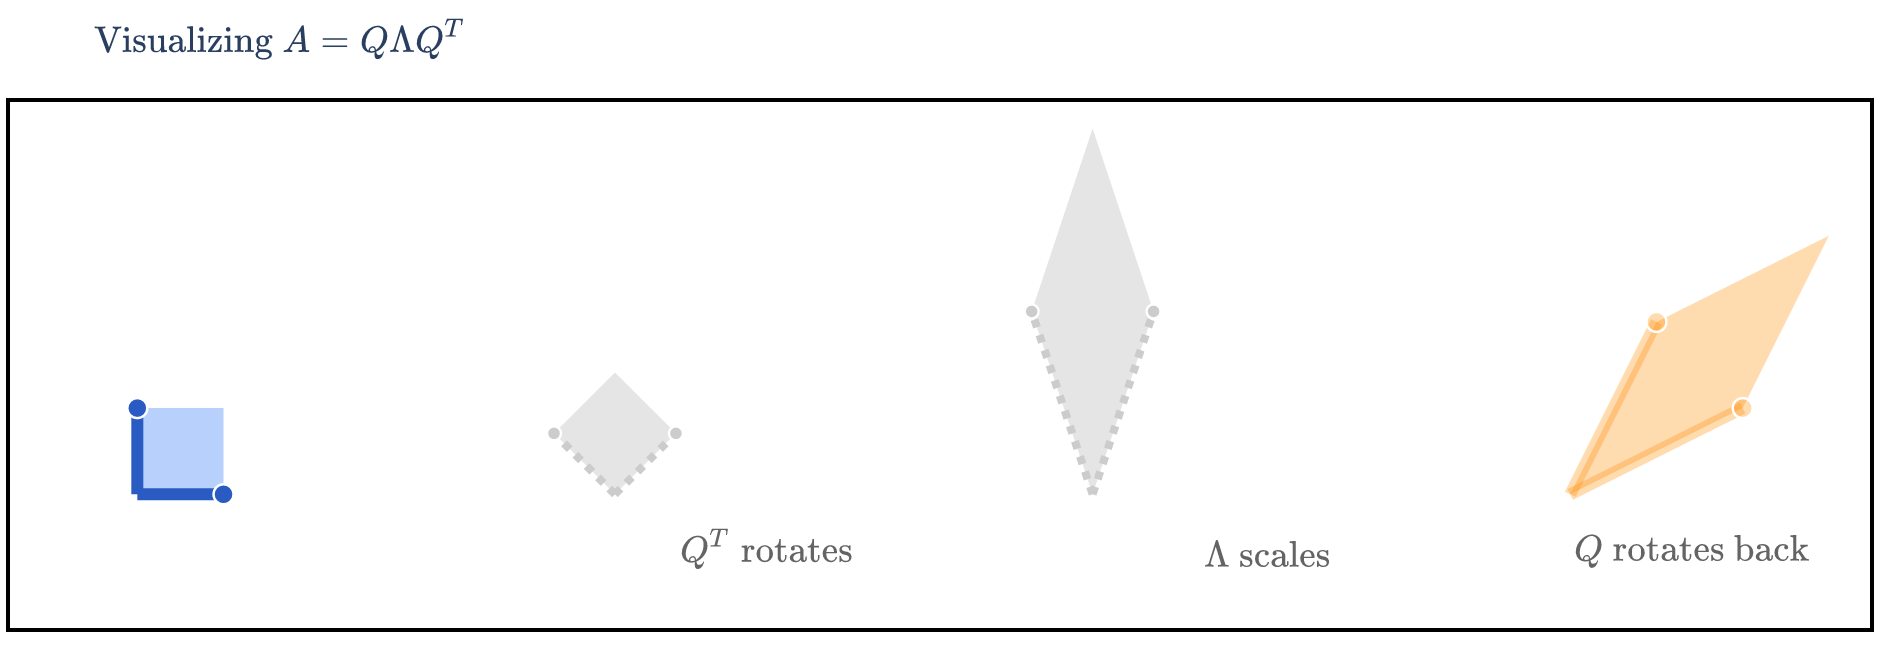

In [113]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_unit_square_diag_process(
    Q,
    Lambda,
    square_color="rgba(61,129,246,0.37)",  # blue for first subplot
    qt_color="rgba(255,140,0,0.31)",  # orange for last
    lqt_color=None,
    qlqt_color=None,
    sq_border_color="rgba(255,255,255,0)",
    show_arrows=True,
    xaxis_range=[-1.5, 3.5],
    yaxis_range=[1, 1],
    title="",
    return_fig=False,
    show_labels=True,
    names=None,  # list of 4 subplot titles
    vector_colors=None,
    vector_label_color="#222"
):
    # Colors for parallelograms
    fill_colors = [square_color, "rgba(180,180,180,0.35)", "rgba(180,180,180,0.35)", qt_color]

    # Arrows: 1st panel = blue, 2/3 = gray, 4th = orange
    BLUE = "#2a5bc2"
    ORANGE = qt_color if qt_color else "#ff8c00"
    GRAY = "#cccccc"
    arrow_colors = [BLUE, GRAY, GRAY, ORANGE]

    # Step labels for bottom right corner (not the first)
    step_labels = ["", r"$$Q^T \text{ rotates}$$", r"$$\Lambda \text{ scales}$$", r"$$Q \text{ rotates back}$$"]

    I = np.eye(2)
    M_list = [
        I,            # original unit square
        Q.T,          # first rotation/reflection
        Lambda @ Q.T, # scaling in new basis
        Q @ Lambda @ Q.T  # rotate back
    ]
    if not names:
        names = [
            r"Unit square",
            r"$Q^T$",
            r"$\Lambda Q^T$",
            r"$Q\Lambda Q^T$"
        ]

    square = np.array([
        [0, 0], [1, 0], [1, 1], [0, 1], [0, 0]
    ])
    u_x = np.array([1, 0])
    u_y = np.array([0, 1])

    fig = make_subplots(rows=1, cols=4,
                        subplot_titles=names,
                        horizontal_spacing=0.025)  # bring plots closer

    # Remove grid, ticks, numbers, and boxes completely
    axis_style = dict(
        showgrid=False,
        zeroline=False,
        showline=False,
        mirror=False,
        showticklabels=False,
        ticks="",
    )
    for j in range(4):
        fig.update_xaxes(range=xaxis_range, constrain="domain", **axis_style, row=1, col=j+1)
        fig.update_yaxes(range=yaxis_range, scaleanchor=f"x{j+1}", **axis_style, row=1, col=j+1)

    for j, M in enumerate(M_list):
        tr_square = (M @ square.T).T
        # Parallelogram
        fig.add_trace(
            go.Scatter(
                x=tr_square[:,0], y=tr_square[:,1],
                fill="toself",
                fillcolor=fill_colors[j],
                line=dict(color=sq_border_color, width=2 if j==0 else 1),
                name="Parallelogram",
                showlegend=False
            ),
            row=1, col=j+1)

        # Draw basis arrows for original and final panels, gray hidden arrows for intermediates
        if show_arrows:
            ux_t = M @ u_x
            uy_t = M @ u_y
            arrowwidth = 6 if j in [0,3] else 4
            arrowdot = 10 if j in [0,3] else 7
            vcolor = arrow_colors[j]
            # Draw for u_x, u_y
            for v, lbl in [(ux_t, r"$\vec u_x$"), (uy_t, r"$\vec u_y$")]:
                # Main arrow line
                fig.add_trace(go.Scatter(
                    x=[0, v[0]], y=[0, v[1]],
                    mode="lines",
                    line=dict(color=vcolor, width=arrowwidth, dash="solid" if j in [0,3] else "dot"),
                    showlegend=False,
                    hoverinfo="skip"
                ), row=1, col=j+1)
                # Arrowhead as dot
                fig.add_trace(go.Scatter(
                    x=[v[0]], y=[v[1]],
                    mode="markers",
                    marker=dict(size=arrowdot, color=vcolor, line=dict(width=1.2, color='white')),
                    showlegend=False,
                    hoverinfo="skip"
                ), row=1, col=j+1)
                # Only draw labels on blue and orange panels, or always if desired
                if show_labels and j in [0, 3]:
                    shift = 0.17 * (v / (np.linalg.norm(v)+1e-8))
                    fig.add_annotation(
                        text=lbl,
                        x=v[0] + shift[0], y=v[1] + shift[1],
                        font=dict(size=16, color=vector_label_color),
                        showarrow=False,
                        xanchor="left", yanchor="bottom",
                        row=1, col=j+1
                    )

        # Add step label in bottom right corner for panels 1,2,3 (not 0)
        if step_labels[j]:
            xr = xaxis_range if isinstance(xaxis_range[0], (int, float)) else xaxis_range[j]
            yr = yaxis_range if isinstance(yaxis_range[0], (int, float)) else yaxis_range[j]
            x_pos = xr[0] + 0.86*(xr[1] - xr[0])
            y_pos = yr[0] + 0.13*(yr[1] - yr[0]) - 2
            fig.add_annotation(
                text=step_labels[j],
                x=x_pos, y=y_pos,
                font=dict(size=20, color="rgba(100,100,100,0.85)", family="Palatino, serif"),
                showarrow=False,
                xanchor='right', yanchor='bottom',
                row=1, col=j+1
            )

    # --- Add box around the entire figure ---
    # We'll do this using a rectangle shape spanning the whole figure/plot coords.
    # Use xref/yref 'paper' so it covers all subplots, with margin fudge.
    fig.add_shape(
        type="rect",
        xref="paper",
        yref="paper",
        x0=0, y0=0,
        x1=1, y1=1,
        line=dict(color="black", width=2),
        fillcolor='rgba(0,0,0,0)',
        layer="above"
    )

    fig.update_layout(
        font=dict(family="Palatino, serif", size=16),
        plot_bgcolor="white",
        paper_bgcolor="white",
        # Whitespace reduced: smaller margins, smaller overall width
        margin=dict(l=4, r=4, t=50, b=10),
        width=940, height=325,
        title=title
    )
    if return_fig:
        return fig
    fig.show(renderer='png', scale=2)

# Example usage:
A = np.array([[1, 2], [2, 1]])
eigvals, eigvecs = np.linalg.eigh(A)
Q = eigvecs
Lambda = np.diag(eigvals)
plot_unit_square_diag_process(
    Q,
    Lambda,
    square_color="rgba(61,129,246,0.37)",
    qt_color="rgba(255,140,0,0.31)",
    # No need for lqt_color, qlqt_color; color ramp is used!
    sq_border_color="rgba(255, 255, 255, 0)",
    xaxis_range=[-1.5, 3.5],
    yaxis_range=[1, 2],
    title=r'$$\text{Visualizing } A = Q \Lambda Q^T$$',
    show_labels=False,
    names=[''] * 4
)

:::{attention} Symmetric matrices rotate, stretch along eigenvectors, and then rotate back!

$$\underbrace{\text{rotate to align with eigenvectors}}_{\text{multiply by } Q^T} \to \underbrace{\text{scale eigenvectors}}_{\text{multiply by } \Lambda} \to \underbrace{\text{rotate back}}_{\text{multiply by } Q}$$

This interpretation is **crucial** to understanding more advanced machine learning techniques, as we'll see in [Chapter 10.1](../10_singular_value_decomposition/01-computing-svd.ipynb).

### The Ellipse Perspective

Another way of visualizing the linear transformation of a symmetric matrix is to consider its effect on the unit **circle**, not the unit square. Below, I'll apply $A = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix}$ to the unit circle.

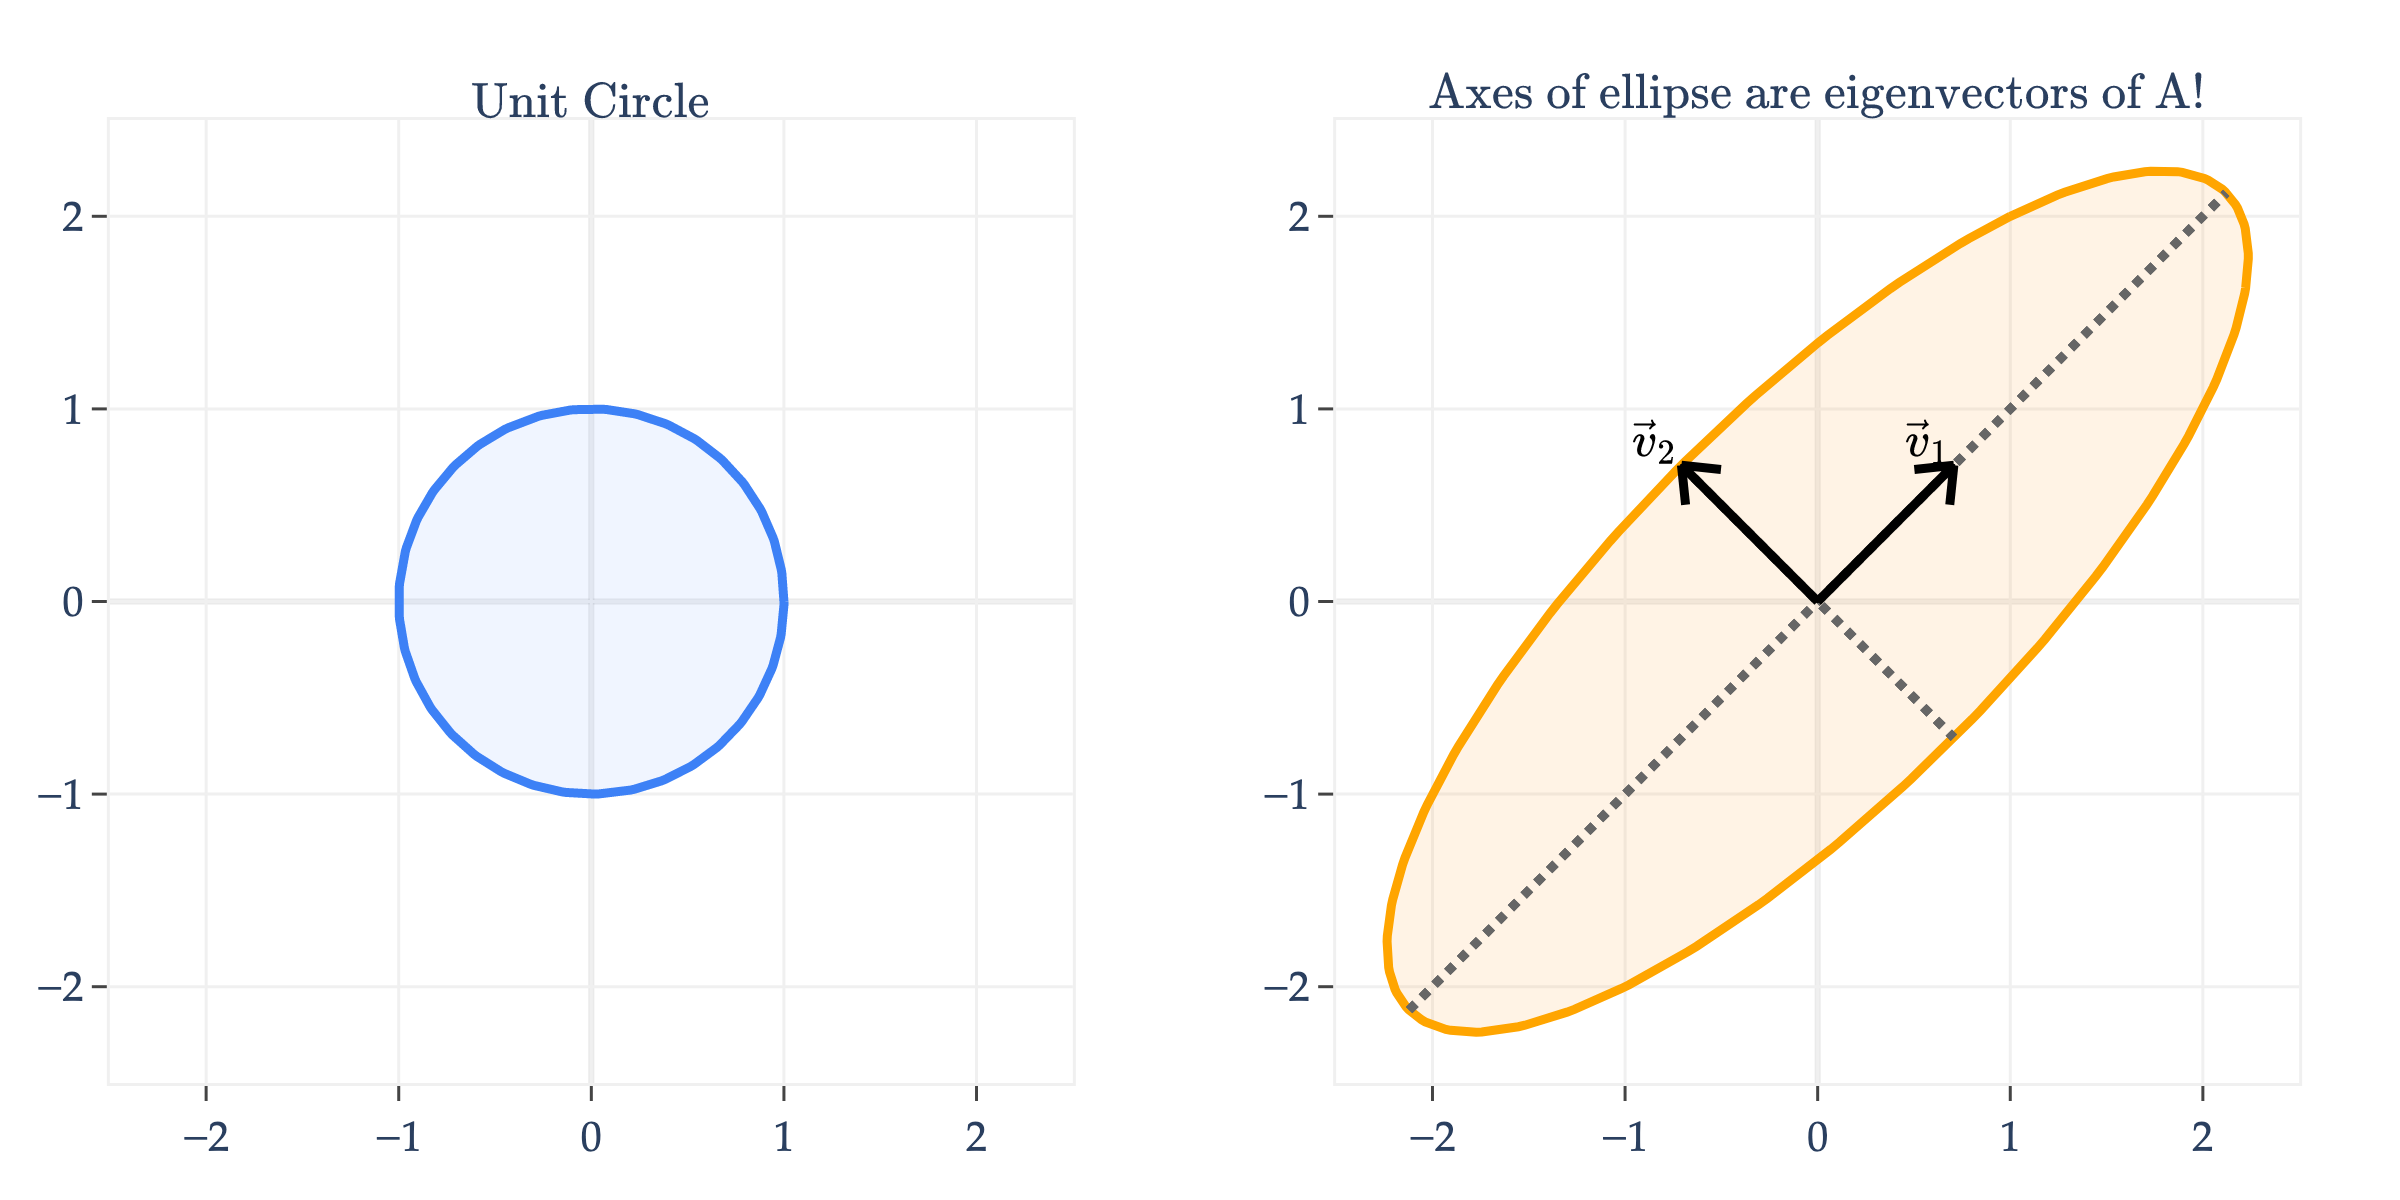

In [112]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_unit_circle_and_transform(S, name="Matrix", show_eig=True, return_fig=False):
    # Generate unit circle points
    theta = np.linspace(0, 2 * np.pi, 300)
    circle = np.vstack((np.cos(theta), np.sin(theta))).T
    # Transformed circle (ellipse)
    ellipse = (S @ circle.T).T

    # Compute real eigenvalues and eigenvectors (for drawing axes)
    try:
        eigvals, eigvecs = np.linalg.eig(S)
    except np.linalg.LinAlgError:
        eigvals, eigvecs = None, None
    # Only retain real-valued eigenvectors for the plot
    real_mask = np.abs(np.imag(eigvals)) < 1e-8
    real_eigvecs = np.real(eigvecs[:, real_mask])
    real_eigvals = np.real(eigvals[real_mask])
    # Normalize eigenvectors for plotting (unit)
    if real_eigvecs.shape[1] > 0:
        eigvec_norms = np.linalg.norm(real_eigvecs, axis=0)
        eigvecs_dir = real_eigvecs / eigvec_norms
    else:
        eigvecs_dir = np.zeros((2,0))

    # Set up figure
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(r"$$\text{Unit Circle}$$", fr"$$\text{{Axes of ellipse are eigenvectors of A!}}$$"),
        horizontal_spacing=0.08
    )

    # Common axis settings: [-2.5,2.5] for each
    axis_style = dict(
        showgrid=True,
        gridcolor="#f0f0f0",
        zeroline=False,
        showline=True,
        linecolor="#f0f0f0",
        mirror=True,
        ticks="outside",
        showticklabels=True,
        tickfont=dict(family="Palatino, serif", size=14),
    )
    # Apply axes settings to both; but you'll hide eigen-directions for left below
    for i in [1, 2]:
        fig.update_xaxes(
            range=[-2.5, 2.5],
            constrain="domain",
            dtick=1,
            **axis_style,
            row=1, col=i
        )
        fig.update_yaxes(
            range=[-2.5, 2.5],
            scaleanchor=f"x{i}",
            dtick=1,
            **axis_style,
            row=1, col=i
        )

    # Grid zero lines under all objects
    for i in [1,2]:
        fig.add_shape(
            type="line",
            x0=-2.5, x1=2.5, y0=0, y1=0,
            line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
            row=1, col=i,
            layer="below"
        )
        fig.add_shape(
            type="line",
            x0=0, x1=0, y0=-2.5, y1=2.5,
            line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
            row=1, col=i,
            layer="below"
        )

    # Left: unit circle (blue)
    fig.add_trace(
        go.Scatter(
            x=circle[:,0], y=circle[:,1],
            line=dict(color="#3d81f6", width=3),
            fill="toself",
            fillcolor="rgba(61,129,246,0.08)",
            name="Unit Circle",
            showlegend=False
        ),
        row=1, col=1
    )
    # Right: transformed circle (ellipse, orange)
    fig.add_trace(
        go.Scatter(
            x=ellipse[:,0], y=ellipse[:,1],
            line=dict(color="orange", width=3),
            fill="toself",
            fillcolor="rgba(255,140,0,0.10)",
            name="Transformed Circle",
            showlegend=False
        ),
        row=1, col=2
    )

    # Plot dotted lines for the (real) eigenvector directions
    # Only show eigenvector axes on right plot, and make them longer and #333 gray
    scale_left = 2.2  # keeps left here for compat but don't plot axes on left
    scale_right_1 = 3  # extend axes more on right plot
    scale_right_m1 = 1
    eig_axis_color = "#666"
    if show_eig and eigvecs_dir.shape[1] > 0:
        for i in range(eigvecs_dir.shape[1]):
            scale_right = scale_right_1 if i == 0 else scale_right_m1
            v = eigvecs_dir[:,i]
            # OMIT left side axes (ellipses axes, i.e. do NOT plot on left)
            # Show extended axes just on right (further and gray)
            for sign in [+1, -1]:
                # Only on right plot (ellipse)
                v_trans = S @ v
                v_trans_norm = np.linalg.norm(v_trans)
                if v_trans_norm > 1e-10:
                    v_trans_unit = v_trans / v_trans_norm
                    fig.add_trace(
                        go.Scatter(
                            x=[-scale_right * v_trans_unit[0], scale_right * v_trans_unit[0]],
                            y=[-scale_right * v_trans_unit[1], scale_right * v_trans_unit[1]],
                            mode="lines",
                            line=dict(color=eig_axis_color, width=3, dash="dot"),
                            name="Transformed Eigenvector",
                            hoverinfo="skip",
                            showlegend=False
                        ),
                        row=1, col=2
                    )

    # ---- Draw [1,1] and [-1,1] as black arrows on top of BOTH plots ----
    arrow_vectors = [np.array([1, 1]) / np.sqrt(2), np.array([-1, 1]) / np.sqrt(2)]
    arrow_colors = ['black', 'black']
    arrow_names = [r"$[1, 1]$", r"$[-1, 1]$"]
    arrow_length = 1  # scale for display

    for col in [2]:
        for idx, vec in enumerate(arrow_vectors):
            # Normalize for direction
            v = vec
            x0, y0 = 0, 0
            x1, y1 = arrow_length * v[0], arrow_length * v[1]
            fig.add_trace(
                go.Scatter(
                    x=[x0, x1],
                    y=[y0, y1],
                    mode="lines+markers",
                    line=dict(color=arrow_colors[idx], width=3),
                    marker=dict(size=1),
                    showlegend=False,
                    hoverinfo="skip"
                ),
                row=1, col=col
            )
            # Custom arrowhead using add_shape for nice head
            fig.add_shape(
                type="line",
                x0=x1-0.16*v[0]-0.13*v[1], y0=y1-0.16*v[1]+0.13*v[0], x1=x1, y1=y1,
                line=dict(color=arrow_colors[idx], width=3),
                row=1, col=col,
                layer="above"
            )
            fig.add_shape(
                type="line",
                x0=x1-0.16*v[0]+0.13*v[1], y0=y1-0.16*v[1]-0.13*v[0], x1=x1, y1=y1,
                line=dict(color=arrow_colors[idx], width=3),
                row=1, col=col,
                layer="above"
            )
            # Optionally add annotation at tip for column 1
            # Only show for one arrow to not clutter
            if col == 2:
                fig.add_annotation(
                    x=x1, y=y1,
                    text=fr"$$\vec v_{{{idx+1}}}$$",
                    showarrow=False,
                    font=dict(color='black', size=16),
                    row=1, col=col,
                    yanchor="bottom",
                    xanchor="right"
                )

    fig.update_layout(
        font=dict(family="Palatino, serif", size=16),
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=20, r=20, t=40, b=20),
        width=800, height=400,
    )

    if return_fig:
        return fig
    fig.show(renderer='png', scale=3)

# Example usage:
A = np.array([[1, 2], [2, 1]])
plot_unit_circle_and_transform(A, name="A")

Notice that $A$ transformed the unit circle into an ellipse. What's more, the **axes of the ellipse are the eigenvector directions of $A$!**

Why is one axis longer than the other? As you might have guessed, the longer axis – the one in the direction of the eigenvector $\vec v_1 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$ – corresponds to the larger eigenvalue. Remember that $A$ has $\lambda_1 = 3$ and $\lambda_2 = -1$, so the "up and to the right" axis is three times longer than the "down and to the right" axis, defined by $\vec v_2 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$.

Why does this happen? Since $A$ is symmetric, it has a spectral decomposition $A = Q \Lambda Q^T$, where $Q$ is orthogonal and $\Lambda$ is diagonal. For any vector $\vec x$, let $\vec y = Q^T \vec x$. Then

$$\vec x^T A \vec x = \vec x^T (Q \Lambda Q^T) \vec x = \vec y^T \Lambda \vec y = \sum_{i=1}^n \lambda_i y_i^2$$

Now imagine that $\vec x$ lies on one of $A$'s eigenvector directions, say the direction of $\vec v_1$. In that case, after rotating by $Q^T$, the vector $\vec y$ has only one non-zero coordinate, namely the coordinate corresponding to $\lambda_1$. So the sum above collapses to

$$\vec x^T A \vec x = \lambda_1 y_1^2$$

Similarly, along the eigenvector direction of $\vec v_2$, we get $\vec x^T A \vec x = \lambda_2 y_2^2$. The size of the output along each principal axis is therefore controlled by the corresponding eigenvalue. Larger eigenvalues produce longer axes, and smaller eigenvalues produce shorter axes. Here, $\lambda_1 = 3$ and $\lambda_2 = -1$, so the axis in the $\vec v_1$ direction is longer in magnitude than the axis in the $\vec v_2$ direction.

---

## Key Takeaways

1. The **eigenvalue decomposition** of a matrix $A$ is a decomposition of the form $$A = V \Lambda V^{-1}$$ where $V$ is a matrix containing the eigenvectors of $A$ as columns, and $\mathcal{\Lambda}$ is a diagonal matrix of eigenvalues in the same order. Only diagonalizable matrices can be decomposed in this way.
1. The **algebraic multiplicity** of an eigenvalue $\mathbf{\lambda}_i$ is the number of times $\mathbf{\lambda}_i$ appears as a root of the characteristic polynomial of $A$.
1. The **geometric multiplicity** of $\mathbf{\lambda}$ is the **dimension of the eigenspace** of $\mathbf{\lambda}$, i.e. $\text{dim}(\text{nullsp}(A - \lambda I))$.
1. The $n \times n$ matrix is **diagonalizable** if and only if any of these equivalent conditions are true:
    - $A$ has $n$ linearly independent eigenvectors.
    - For every eigenvalue $\lambda_i$, $\text{GM}(\lambda_i) = \text{AM}(\lambda_i)$.
    When $A$ is diagonalizable, it has an eigenvalue decomposition, $A = V \Lambda V^{-1}$.
1. If $A$ is a symmetric matrix, then the **spectral theorem** tells us that $A$ can be diagonalized by an orthogonal matrix $Q$ such that $$A = Q \Lambda Q^T$$ and that all of $A$'s eigenvalues are guaranteed to be real.

What's next? There's the question of **how any of this relates to real data**. Real data comes in rectangular matrices, not square matrices. And even it were square, how does any of this enlighten us?